In [1]:
!pip install pandas openpyxl scikit-learn statsmodels xgboost prophet tensorflow fastapi uvicorn nest-asyncio pyngrok

In [2]:
from google.colab import files
uploaded = files.upload()  # A button will appear — upload your sales_data.xlsx

Saving Forecasting Case- Study (1).xlsx to Forecasting Case- Study (1) (1).xlsx


In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Load the uploaded file
df = pd.read_excel("Forecasting Case- Study (1) (1).xlsx")
df.columns = ['state', 'date', 'sales', 'category']
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['state', 'date']).reset_index(drop=True)

print("✅ Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"States: {df['state'].nunique()}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Missing values: {df.isnull().sum().sum()}")
print("\nFirst 5 rows:")
df.head()

✅ Data loaded successfully!
Shape: (8084, 4)
States: 43
Date range: 2019-01-12 to 2023-12-03
Missing values: 0

First 5 rows:


,state,date,sales,category
0,Alabama,2019-01-12,109574036.0,Beverages
1,Alabama,2019-03-11,112189103.8,Beverages
2,Alabama,2019-06-10,129106730.4,Beverages
3,Alabama,2019-08-12,108083723.8,Beverages
4,Alabama,2019-10-11,110932912.8,Beverages


In [4]:
def add_features(state_df):
    state_df = state_df.copy().sort_values('date').reset_index(drop=True)

    # Time features
    state_df['day_of_week']  = state_df['date'].dt.dayofweek
    state_df['month']        = state_df['date'].dt.month
    state_df['quarter']      = state_df['date'].dt.quarter
    state_df['week_of_year'] = state_df['date'].dt.isocalendar().week.astype(int)
    state_df['year']         = state_df['date'].dt.year
    state_df['trend']        = np.arange(len(state_df))

    # Lag features
    state_df['lag_1']  = state_df['sales'].shift(1)
    state_df['lag_4']  = state_df['sales'].shift(4)
    state_df['lag_8']  = state_df['sales'].shift(8)
    state_df['lag_52'] = state_df['sales'].shift(52)

    # Rolling features
    state_df['rolling_mean_4']  = state_df['sales'].shift(1).rolling(4).mean()
    state_df['rolling_mean_8']  = state_df['sales'].shift(1).rolling(8).mean()
    state_df['rolling_mean_12'] = state_df['sales'].shift(1).rolling(12).mean()
    state_df['rolling_std_4']   = state_df['sales'].shift(1).rolling(4).std()
    state_df['rolling_std_8']   = state_df['sales'].shift(1).rolling(8).std()

    state_df = state_df.dropna().reset_index(drop=True)
    return state_df

FEATURE_COLS = [
    'lag_1','lag_4','lag_8','lag_52',
    'rolling_mean_4','rolling_mean_8','rolling_mean_12',
    'rolling_std_4','rolling_std_8',
    'day_of_week','month','quarter','week_of_year','year','trend'
]

# Test it on Alabama
sample = df[df['state']=='Alabama'].copy()
sample_featured = add_features(sample)
print("✅ Feature engineering works!")
print(f"Features created: {len(FEATURE_COLS)}")
print(f"Sample shape after features: {sample_featured.shape}")
print("\nFeature columns:")
print(FEATURE_COLS)

✅ Feature engineering works!
Features created: 15
Sample shape after features: (136, 19)

Feature columns:
['lag_1', 'lag_4', 'lag_8', 'lag_52', 'rolling_mean_4', 'rolling_mean_8', 'rolling_mean_12', 'rolling_std_4', 'rolling_std_8', 'day_of_week', 'month', 'quarter', 'week_of_year', 'year', 'trend']


In [5]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import json, warnings
warnings.filterwarnings("ignore")
tf.get_logger().setLevel('ERROR')

VAL_WEEKS = 16
FORECAST_WEEKS = 8

def rmse(actual, pred):
    return float(np.sqrt(mean_squared_error(actual, pred)))

# ── ARIMA ──────────────────────────────────────────────────────
def run_arima(state_df):
    sales = state_df['sales'].values
    train, val = sales[:-VAL_WEEKS], sales[-VAL_WEEKS:]
    try:
        m = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,0,12),
                    enforce_stationarity=False, enforce_invertibility=False)
        r = m.fit(disp=False)
        pred = r.forecast(VAL_WEEKS)
        score = rmse(val, pred)
        # refit full
        mf = SARIMAX(sales, order=(1,1,1), seasonal_order=(1,1,0,12),
                     enforce_stationarity=False, enforce_invertibility=False)
        rf = mf.fit(disp=False)
        forecast = rf.forecast(FORECAST_WEEKS).tolist()
        return score, forecast
    except:
        return None, None

# ── Prophet ────────────────────────────────────────────────────
def run_prophet(state_df):
    pdf = state_df[['date','sales']].rename(columns={'date':'ds','sales':'y'})
    train, val = pdf.iloc[:-VAL_WEEKS], pdf.iloc[-VAL_WEEKS:]
    try:
        m = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                    daily_seasonality=False, seasonality_mode='multiplicative')
        m.fit(train)
        future = m.make_future_dataframe(periods=VAL_WEEKS+FORECAST_WEEKS, freq='W')
        fc = m.predict(future)
        pred = fc.iloc[-VAL_WEEKS-FORECAST_WEEKS:-FORECAST_WEEKS]['yhat'].values
        score = rmse(val['y'].values, pred)
        forecast = fc.tail(FORECAST_WEEKS)['yhat'].tolist()
        return score, forecast
    except:
        return None, None

# ── XGBoost ────────────────────────────────────────────────────
def run_xgboost(state_df):
    df_feat = add_features(state_df)
    train, val = df_feat.iloc[:-VAL_WEEKS], df_feat.iloc[-VAL_WEEKS:]
    try:
        m = XGBRegressor(n_estimators=300, learning_rate=0.05,
                         max_depth=4, random_state=42, verbosity=0)
        m.fit(train[FEATURE_COLS], train['sales'],
              eval_set=[(val[FEATURE_COLS], val['sales'])], verbose=False)
        pred = m.predict(val[FEATURE_COLS])
        score = rmse(val['sales'].values, pred)
        # rolling forecast
        last_sales = list(df_feat['sales'].values)
        last_date  = state_df['date'].max()
        last_trend = df_feat['trend'].iloc[-1]
        preds = []
        for i in range(FORECAST_WEEKS):
            nd = last_date + pd.Timedelta(weeks=i+1)
            row = {
                'lag_1': last_sales[-1], 'lag_4': last_sales[-4],
                'lag_8': last_sales[-8],
                'lag_52': last_sales[-52] if len(last_sales)>=52 else last_sales[0],
                'rolling_mean_4': np.mean(last_sales[-4:]),
                'rolling_mean_8': np.mean(last_sales[-8:]),
                'rolling_mean_12': np.mean(last_sales[-12:]),
                'rolling_std_4': np.std(last_sales[-4:]),
                'rolling_std_8': np.std(last_sales[-8:]),
                'day_of_week': nd.dayofweek, 'month': nd.month,
                'quarter': nd.quarter,
                'week_of_year': nd.isocalendar()[1],
                'year': nd.year, 'trend': last_trend + i + 1
            }
            p = float(m.predict(np.array([[row[c] for c in FEATURE_COLS]]))[0])
            preds.append(p)
            last_sales.append(p)
        return score, preds
    except:
        return None, None

# ── LSTM ───────────────────────────────────────────────────────
def run_lstm(state_df, lookback=12):
    sales = state_df['sales'].values.astype(float)
    mn, mx = sales.min(), sales.max()
    scaled = (sales - mn) / (mx - mn + 1e-8)
    X, y = [], []
    for i in range(lookback, len(scaled)):
        X.append(scaled[i-lookback:i])
        y.append(scaled[i])
    X, y = np.array(X), np.array(y)
    X_train, X_val = X[:-VAL_WEEKS], X[-VAL_WEEKS:]
    y_train, y_val = y[:-VAL_WEEKS], y[-VAL_WEEKS:]
    X_train = X_train.reshape(-1, lookback, 1)
    X_val   = X_val.reshape(-1, lookback, 1)
    try:
        model = Sequential([
            LSTM(64, return_sequences=True, input_shape=(lookback,1)),
            Dropout(0.2), LSTM(32), Dropout(0.2), Dense(1)
        ])
        model.compile(optimizer='adam', loss='mse')
        model.fit(X_train, y_train, epochs=80, batch_size=16,
                  validation_data=(X_val, y_val),
                  callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
                  verbose=0)
        pred_scaled = model.predict(X_val, verbose=0).flatten()
        pred = pred_scaled * (mx - mn) + mn
        score = rmse(y_val * (mx - mn) + mn, pred)
        # forecast
        seq = list(scaled[-lookback:])
        preds = []
        for _ in range(FORECAST_WEEKS):
            xin = np.array(seq[-lookback:]).reshape(1, lookback, 1)
            p = float(model.predict(xin, verbose=0)[0][0])
            preds.append(p * (mx - mn) + mn)
            seq.append(p)
        return score, preds
    except:
        return None, None

# ── MAIN TRAINING LOOP ─────────────────────────────────────────
import pandas as pd
from collections import Counter

states = sorted(df['state'].unique())
all_results = {}
model_wins  = Counter()

print(f"🚀 Training models for {len(states)} states...\n")

for i, state in enumerate(states):
    state_df = df[df['state']==state].copy().sort_values('date').reset_index(drop=True)
    last_date = state_df['date'].max()
    future_dates = [(last_date + pd.Timedelta(weeks=w+1)).strftime('%Y-%m-%d')
                    for w in range(FORECAST_WEEKS)]
    scores, forecasts = {}, {}

    arima_s,   arima_f   = run_arima(state_df)
    prophet_s, prophet_f = run_prophet(state_df)
    xgb_s,     xgb_f     = run_xgboost(state_df)
    lstm_s,    lstm_f     = run_lstm(state_df)

    if arima_s:   scores['ARIMA']   = arima_s;   forecasts['ARIMA']   = arima_f
    if prophet_s: scores['Prophet'] = prophet_s; forecasts['Prophet'] = prophet_f
    if xgb_s:     scores['XGBoost'] = xgb_s;     forecasts['XGBoost'] = xgb_f
    if lstm_s:    scores['LSTM']    = lstm_s;     forecasts['LSTM']    = lstm_f

    if not scores:
        print(f"  [{i+1}/{len(states)}] {state} — all models failed ❌")
        continue

    best = min(scores, key=scores.get)
    model_wins[best] += 1
    forecast_vals = forecasts[best]

    all_results[state] = {
        "best_model": best,
        "model_scores_rmse": {k: round(v,2) for k,v in scores.items()},
        "forecast": [
            {"week": w+1, "date": future_dates[w],
             "predicted_sales": round(float(forecast_vals[w]), 2)}
            for w in range(FORECAST_WEEKS)
        ]
    }
    print(f"  [{i+1}/{len(states)}] {state:20s} → Best: {best:8s} RMSE={scores[best]:>15,.0f}")

print(f"\n✅ Training complete! {len(all_results)}/{len(states)} states done")
print(f"\n🏆 Model wins: {dict(model_wins)}")

# Save results
with open('forecasts.json', 'w') as f:
    json.dump(all_results, f, indent=2)
print("💾 Saved to forecasts.json")

🚀 Training models for 43 states...

  [1/43] Alabama              → Best: LSTM     RMSE=     11,020,599
  [2/43] Arizona              → Best: LSTM     RMSE=     14,548,174
  [3/43] Arkansas             → Best: XGBoost  RMSE=      5,480,255
  [4/43] California           → Best: LSTM     RMSE=     42,518,065
  [5/43] Colorado             → Best: LSTM     RMSE=      8,713,554
  [6/43] Connecticut          → Best: XGBoost  RMSE=      3,982,768
  [7/43] Florida              → Best: LSTM     RMSE=     41,149,646
  [8/43] Georgia              → Best: XGBoost  RMSE=     18,961,406
  [9/43] Illinois             → Best: XGBoost  RMSE=     16,062,951
  [10/43] Indiana              → Best: XGBoost  RMSE=     10,832,687
  [11/43] Iowa                 → Best: XGBoost  RMSE=      6,248,596
  [12/43] Kansas               → Best: XGBoost  RMSE=      4,223,188
  [13/43] Kentucky             → Best: XGBoost  RMSE=      8,760,297
  [14/43] Louisiana            → Best: LSTM     RMSE=     10,627,242
  [15/4

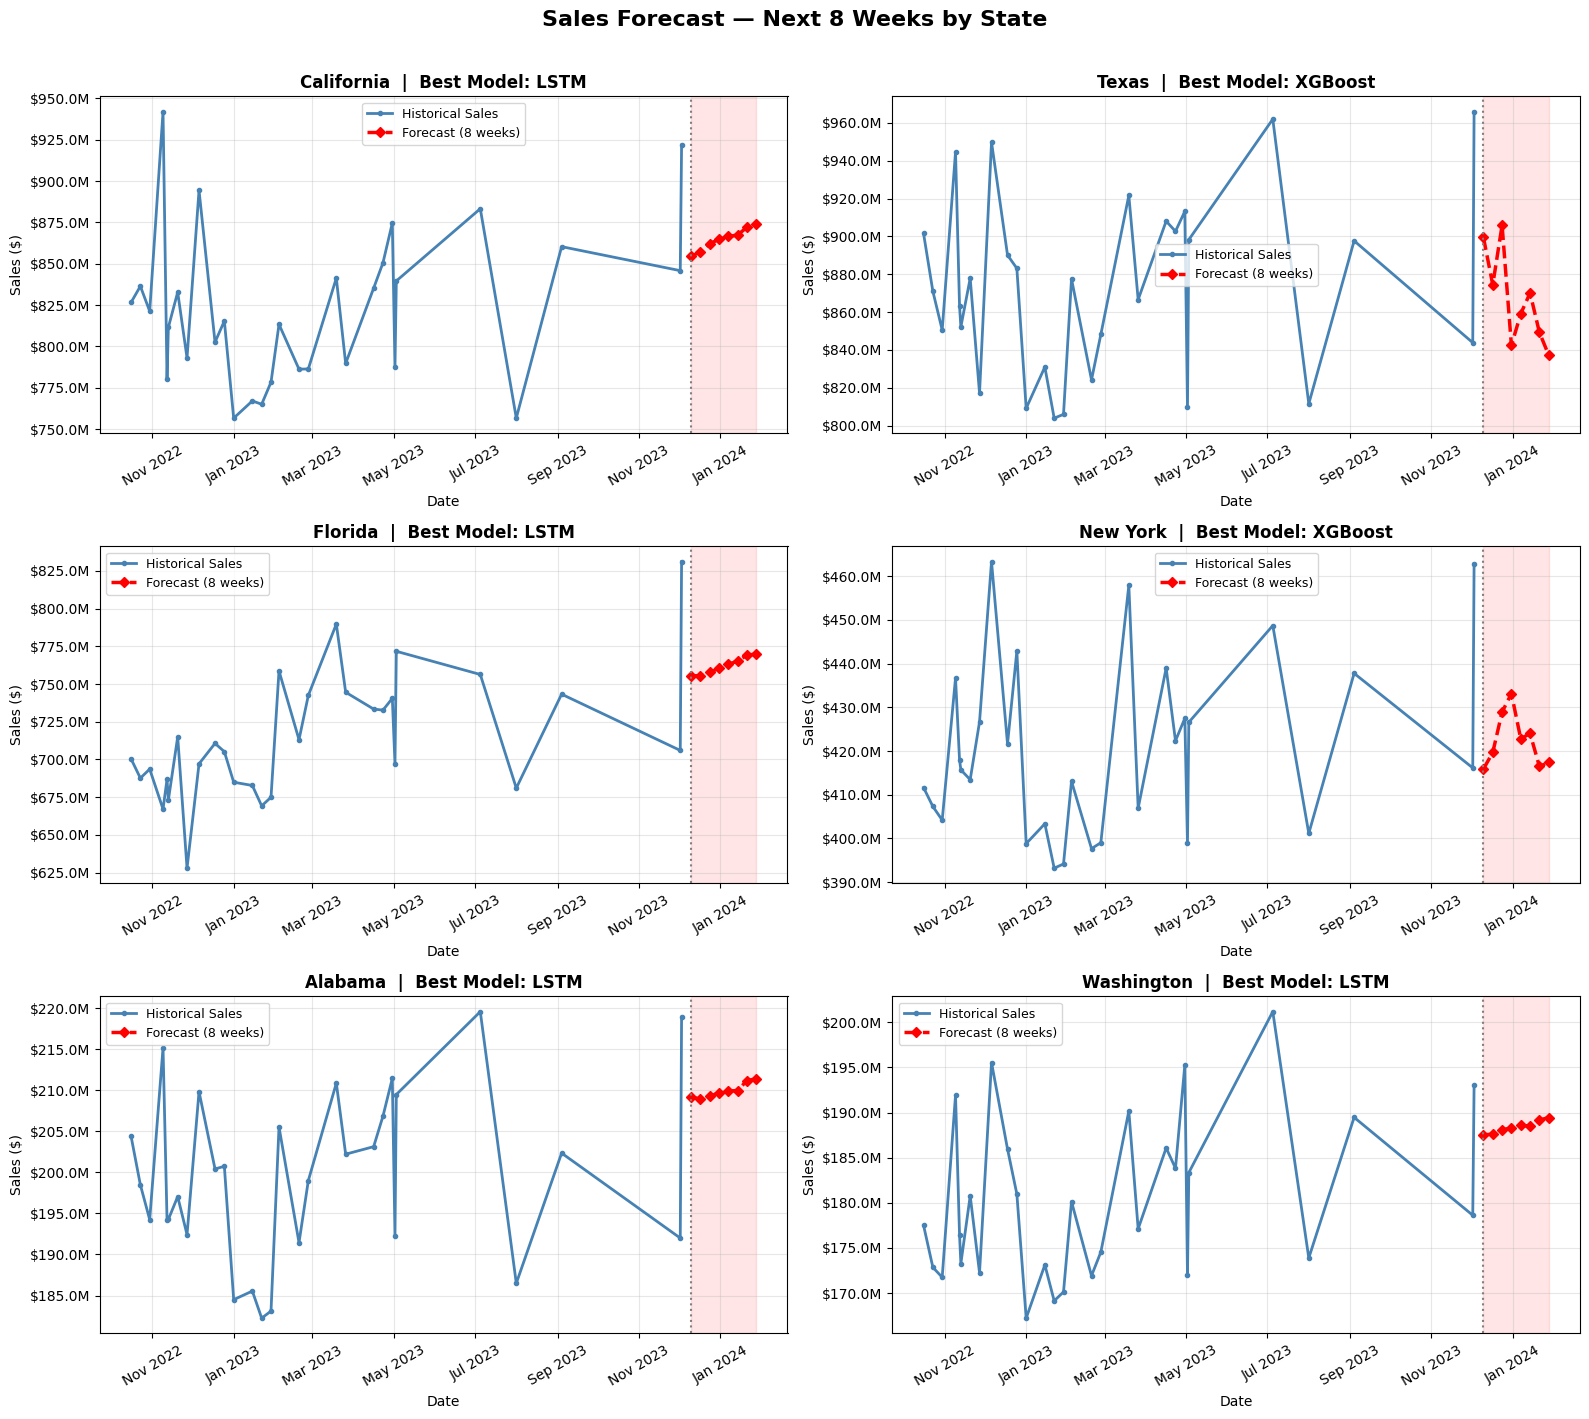

✅ Charts saved!


In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Pick 6 states to visualize
sample_states = ['California', 'Texas', 'Florida', 'New York', 'Alabama', 'Washington']

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, state in enumerate(sample_states):
    ax = axes[idx]
    result = all_results[state]

    # Historical data
    state_df = df[df['state']==state].sort_values('date')

    # Forecast data
    fc_dates = [pd.to_datetime(x['date']) for x in result['forecast']]
    fc_vals  = [x['predicted_sales'] for x in result['forecast']]

    # Plot historical (last 30 points)
    ax.plot(state_df['date'].tail(30), state_df['sales'].tail(30),
            color='steelblue', linewidth=2, label='Historical Sales', marker='o', markersize=3)

    # Plot forecast
    ax.plot(fc_dates, fc_vals,
            color='red', linewidth=2.5, label=f'Forecast (8 weeks)',
            marker='D', markersize=5, linestyle='--')

    # Shade forecast area
    ax.axvspan(fc_dates[0], fc_dates[-1], alpha=0.1, color='red')

    # Vertical line at forecast start
    ax.axvline(x=fc_dates[0], color='gray', linestyle=':', linewidth=1.5)

    ax.set_title(f'{state}  |  Best Model: {result["best_model"]}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Sales ($)')
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.suptitle('Sales Forecast — Next 8 Weeks by State',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('forecast_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Charts saved!")

In [8]:
import nest_asyncio
import uvicorn
from fastapi import FastAPI, HTTPException
from fastapi.responses import JSONResponse
import json, threading
nest_asyncio.apply()

# Load forecasts
with open('forecasts.json') as f:
    all_forecasts = json.load(f)

app = FastAPI(title="Sales Forecasting API")

@app.get("/")
def home():
    return {
        "message": "Sales Forecasting API is running!",
        "total_states": len(all_forecasts),
        "endpoints": {
            "GET /states":           "List all states",
            "GET /forecast/{state}": "8-week forecast for a state",
            "GET /scores/{state}":   "Model scores for a state",
            "GET /best-models":      "Which model won per state",
            "GET /summary":          "Overall summary"
        }
    }

@app.get("/states")
def get_states():
    return {"total": len(all_forecasts), "states": sorted(all_forecasts.keys())}

@app.get("/forecast/{state}")
def get_forecast(state: str):
    match = next((k for k in all_forecasts if k.lower()==state.lower()), None)
    if not match:
        raise HTTPException(status_code=404, detail=f"State '{state}' not found.")
    result = all_forecasts[match]
    return {"state": match, "best_model": result["best_model"], "forecast": result["forecast"]}

@app.get("/scores/{state}")
def get_scores(state: str):
    match = next((k for k in all_forecasts if k.lower()==state.lower()), None)
    if not match:
        raise HTTPException(status_code=404, detail=f"State '{state}' not found.")
    result = all_forecasts[match]
    return {"state": match, "best_model": result["best_model"], "model_scores": result["model_scores_rmse"]}

@app.get("/best-models")
def best_models():
    from collections import Counter
    bm = {s: v["best_model"] for s, v in all_forecasts.items()}
    counts = Counter(bm.values())
    return {"model_win_counts": dict(counts), "by_state": bm}

@app.get("/summary")
def summary():
    from collections import Counter
    counts = Counter(v["best_model"] for v in all_forecasts.values())
    return {
        "total_states": len(all_forecasts),
        "forecast_weeks": 8,
        "model_wins": dict(counts),
        "winner_overall": counts.most_common(1)[0][0]
    }

print("✅ API is running!")
print("\n🔗 Test these in the next cell:")
print("   GET /states")
print("   GET /forecast/California")
print("   GET /best-models")
print("   GET /summary")

# Run in background thread
def run():
    uvicorn.run(app, host="0.0.0.0", port=8000, log_level="error")

t = threading.Thread(target=run, daemon=True)
t.start()
print("\n🚀 Server started on port 8000!")

✅ API is running!

🔗 Test these in the next cell:
   GET /states
   GET /forecast/California
   GET /best-models
   GET /summary

🚀 Server started on port 8000!


In [9]:
import requests

base = "http://localhost:8000"

print("=" * 50)
print("TEST 1: Home")
print(requests.get(f"{base}/").json()['message'])

print("\nTEST 2: All States")
r = requests.get(f"{base}/states").json()
print(f"Total states: {r['total']}")
print(f"First 5: {r['states'][:5]}")

print("\nTEST 3: Forecast California")
r = requests.get(f"{base}/forecast/California").json()
print(f"Best model: {r['best_model']}")
for w in r['forecast']:
    print(f"  Week {w['week']} ({w['date']}): ${w['predicted_sales']:,.0f}")

print("\nTEST 4: Model Scores - Texas")
r = requests.get(f"{base}/scores/Texas").json()
print(f"Best model: {r['best_model']}")
for m, s in r['model_scores'].items():
    print(f"  {m}: RMSE = {s:,.0f}")

print("\nTEST 5: Best Models Summary")
r = requests.get(f"{base}/best-models").json()
print(f"Model wins: {r['model_win_counts']}")

print("\n✅ ALL API TESTS PASSED!")

TEST 1: Home
Sales Forecasting API is running!

TEST 2: All States
Total states: 43
First 5: ['Alabama', 'Arizona', 'Arkansas', 'California', 'Colorado']

TEST 3: Forecast California
Best model: LSTM
  Week 1 (2023-12-10): $854,389,300
  Week 2 (2023-12-17): $857,177,698
  Week 3 (2023-12-24): $862,114,154
  Week 4 (2023-12-31): $864,680,572
  Week 5 (2024-01-07): $866,519,069
  Week 6 (2024-01-14): $867,343,052
  Week 7 (2024-01-21): $872,052,015
  Week 8 (2024-01-28): $874,171,471

TEST 4: Model Scores - Texas
Best model: XGBoost
  ARIMA: RMSE = 88,385,879
  Prophet: RMSE = 170,754,088
  XGBoost: RMSE = 47,487,133
  LSTM: RMSE = 50,514,395

TEST 5: Best Models Summary
Model wins: {'LSTM': 20, 'XGBoost': 23}

✅ ALL API TESTS PASSED!


In [10]:
from google.colab import files
files.download('forecasts.json')
files.download('forecast_charts.png')
print("✅ Files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Files downloaded!


# New Section